# Brain Tumor Data Cleaning

This notebook cleans 'brain_tumor_dirty.csv'.

1. Remove duplicate patients.
2. Standardize 'Tumor Type' casing ('glioma' to 'Glioma', etc.).
3. Fix invalid 'Age' values (a sentinel '999' appeared 10 times) in the dirty dataset.
4. Fix invalid 'Tumor Size (cm)' values ( negative values).
5. Format 'Date of Diagnosis' correctly.


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load dataset into a pandas DataFrame
df = pd.read_csv('brain_tumor_dirty.csv')

In [5]:
# To check the first 5 rows of the DataFrame
df.head()

,Patient ID,Age,Gender,Tumor Type,Tumor Grade,Affected Brain Region,Tumor Size (cm),Symptoms,Laterality,Histology Confirmation,Treatment Type,Date of Diagnosis
0,P08705,73.0,Male,Glioma,Grade 4,Frontal,6.4,"Behavioral changes, Headache, Weakness",Left,Confirmed,Surgery,1/21/2022
1,P05805,69.0,Male,Glioma,Grade 2,Frontal,3.1,"Weakness, Behavioral changes",Right,Confirmed,Surgery,8/22/2025
2,P08342,43.0,Female,Meningioma,Grade 1,NaN,1.2,"Sensory deficits, Weakness",Left,Unconfirmed,Surgery,6/1/2017
3,P01264,62.0,Female,Meningioma,Grade 1,Parietal,2.3,"Weakness, Sensory deficits",Left,Confirmed,Observation,6/1/2016
4,P06289,20.0,Male,Ependymoma,Grade 3,Brainstem,6.6,"Cranial nerve deficits, Difficulty swallowing,...",Right,Confirmed,Surgery,4/25/2020


In [6]:
# Get the count of rows and columns in the DataFrame
df.shape

(10210, 12)

## 1. Remove duplicate patients

The dirty file has 10,210 rows. We keep the first occurrence of each patient.

In [7]:
# Remove duplicate rows from the DataFrame
print("Rows before dedup:", df.shape[0])
print("Duplicate Patient IDs:", df['Patient ID'].duplicated().sum())

df = df.drop_duplicates(subset='Patient ID', keep='first').reset_index(drop=True)

print("Rows after dedup:", df.shape[0])

Rows before dedup: 10210
Duplicate Patient IDs: 210
Rows after dedup: 10000


## 2. Check for missing values

In [8]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
missing_values

Patient ID                  0
Age                       300
Gender                    200
Tumor Type                  0
Tumor Grade               200
Affected Brain Region     200
Tumor Size (cm)           400
Symptoms                  515
Laterality                300
Histology Confirmation    200
Treatment Type            300
Date of Diagnosis           2
dtype: int64

In [9]:
# To check the data types of each column in the DataFrame
df.dtypes

Patient ID                 object
Age                       float64
Gender                     object
Tumor Type                 object
Tumor Grade                object
Affected Brain Region      object
Tumor Size (cm)           float64
Symptoms                   object
Laterality                 object
Histology Confirmation     object
Treatment Type             object
Date of Diagnosis          object
dtype: object

## 3. Fix 'Age'

Convert to numeric, then correct the '999' sentinel value (an obvious data-entry error — the max valid age in this dataset should be under 100).

In [10]:
# Convert the 'Age' column to numeric, coercing errors, and set the type to 'Int64'
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# 999 is a sentinel/error code, not a real age — treat it as missing
print("Rows with Age == 999:", (df['Age'] == 999).sum())
df.loc[df['Age'] == 999, 'Age'] = pd.NA

df['Age'].describe()

Rows with Age == 999: 10


count    9690.000000
mean       44.918369
std        19.196934
min         5.000000
25%        31.000000
50%        47.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64

In [11]:

df.dtypes

Patient ID                 object
Age                       float64
Gender                     object
Tumor Type                 object
Tumor Grade                object
Affected Brain Region      object
Tumor Size (cm)           float64
Symptoms                   object
Laterality                 object
Histology Confirmation     object
Treatment Type             object
Date of Diagnosis          object
dtype: object

## 4. Fix 'Tumor Size (cm)'

Convert to numeric and correct negative sizes, by taking the absolute value.

In [18]:
df['Tumor Size (cm)'] = pd.to_numeric(df['Tumor Size (cm)'], errors='coerce')

print("Rows with negative Tumor Size:", (df['Tumor Size (cm)'] < 0).sum())
neg_mask = df['Tumor Size (cm)'] < 0
df.loc[neg_mask, 'Tumor Size (cm)'] = df.loc[neg_mask, 'Tumor Size (cm)'].abs()

df['Tumor Size (cm)'].describe()

Rows with negative Tumor Size: 0


count    9600.000000
mean        4.383990
std         2.195142
min         1.000000
25%         2.300000
50%         4.800000
75%         6.400000
max         8.000000
Name: Tumor Size (cm), dtype: float64

## 5. Convert 'Date of Diagnosis' (mixed formats)

The raw column mixes sseveral different date formats

In [19]:
def parse_date(value):
    if pd.isna(value):
        return pd.NaT
    text = str(value).strip()
    known_formats = ['%Y/%m/%d', '%Y-%m-%d', '%d-%m-%Y', '%m-%d-%y', '%m/%d/%Y']
    for fmt in known_formats:
        parsed = pd.to_datetime(text, format=fmt, errors='coerce')
        if pd.notna(parsed):
            return parsed
    # fall back to free-text dates like "July 28, 2023"
    return pd.to_datetime(text, errors='coerce')

df['Date of Diagnosis'] = df['Date of Diagnosis'].apply(parse_date)
df['Date of Diagnosis'].isna().sum()

np.int64(3301)

In [21]:
df.dtypes

Patient ID                        object
Age                              float64
Gender                            object
Tumor Type                        object
Tumor Grade                       object
Affected Brain Region             object
Tumor Size (cm)                  float64
Symptoms                          object
Laterality                        object
Histology Confirmation            object
Treatment Type                    object
Date of Diagnosis         datetime64[ns]
dtype: object

## 6. Fix remaining missing values

Numeric columns are filled with the median, categorical columns with the mode. And for entries that were genuinely missing or corrupted in the raw data, imputation will be used to only approximate the original value.

In [23]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age).astype('Int64')

median_tumor_size = df['Tumor Size (cm)'].median()
df['Tumor Size (cm)'] = df['Tumor Size (cm)'].fillna(median_tumor_size)

mode_date = df['Date of Diagnosis'].mode()[0]
df['Date of Diagnosis'] = df['Date of Diagnosis'].fillna(mode_date)

mode_gender = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].fillna(mode_gender)

categorical_cols = ['Tumor Grade', 'Affected Brain Region', 'Symptoms',
                    'Laterality', 'Histology Confirmation', 'Treatment Type']
for col in categorical_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)



In [24]:
# Check for missing values in the DataFrame after cleaning
df.isnull().sum()

Patient ID                0
Age                       0
Gender                    0
Tumor Type                0
Tumor Grade               0
Affected Brain Region     0
Tumor Size (cm)           0
Symptoms                  0
Laterality                0
Histology Confirmation    0
Treatment Type            0
Date of Diagnosis         0
dtype: int64

## 7. Standardize text formatting

Both 'Gender' and 'Tumor Type' have inconsistent casing/whitespace in the raw data (e.g. "  Male  ", "FEMALE", "glioma", "MENINGIOMA").

In [25]:
# Clean up string columns by stripping whitespace and standardizing capitalization
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Tumor Type'] = df['Tumor Type'].str.strip().str.title()

print(df['Gender'].value_counts())
print()
print(df['Tumor Type'].value_counts())

Gender
Female    5777
Male      4223
Name: count, dtype: int64

Tumor Type
Glioma             4058
Meningioma         3055
Medulloblastoma    1001
Ependymoma          961
Pituitary Tumor     925
Name: count, dtype: int64


## 8. Sort by Patient ID

In [28]:
# Sort the DataFrame by 'Patient ID' and reset the index
df = df.sort_values(by='Patient ID').reset_index(drop=True)
df.head()

,Patient ID,Age,Gender,Tumor Type,Tumor Grade,Affected Brain Region,Tumor Size (cm),Symptoms,Laterality,Histology Confirmation,Treatment Type,Date of Diagnosis
0,P00001,41,Male,Glioma,Grade 1,Frontal,2.9,Weakness,Left,Confirmed,Observation,2022-03-04
1,P00002,11,Male,Ependymoma,Grade 3,Cerebellum,6.8,"Balance issues, Dizziness, Coordination problems",Right,Confirmed,Radiation,2016-04-01
2,P00003,23,Male,Pituitary Tumor,Grade 1,Pituitary,1.6,"Headache, Vision problems",Left,Confirmed,Observation,2015-04-13
3,P00004,52,Female,Meningioma,Grade 1,Parietal,2.3,"Sensory deficits, Coordination issues",Bilateral,Confirmed,Surgery,2016-01-17
4,P00005,32,Male,Glioma,Grade 4,Temporal,7.6,"Memory loss, Seizures, Speech difficulties",Left,Confirmed,Radiation,2016-01-17


In [29]:
df.shape

(10000, 12)

## 9. Validate against the reference clean file

In [32]:
reference = pd.read_csv('brain_tumor_dirty.csv')

print("Cleaned shape:  ", df.shape)
print("Reference shape:", reference.shape)
print()
print("Tumor Type counts match:",
      df['Tumor Type'].value_counts().equals(reference['Tumor Type'].value_counts()))
print("Gender counts (cleaned):\n", df['Gender'].value_counts())
print("Gender counts (reference):\n", reference['Gender'].value_counts())

Cleaned shape:   (10000, 12)
Reference shape: (10210, 12)

Tumor Type counts match: False
Gender counts (cleaned):
 Gender
Female    5777
Male      4223
Name: count, dtype: int64
Gender counts (reference):
 Gender
Female        5651
Male          4258
  Female        19
FEMALE          18
  Male          18
female          17
male            13
MALE            12
Name: count, dtype: int64


## 10. Exploratory checks (from the cleaned dataset)

In [33]:
# Count of each unique 'Tumor Type'
tumor_type_counts = df['Tumor Type'].value_counts()
tumor_type_counts

Tumor Type
Glioma             4058
Meningioma         3055
Medulloblastoma    1001
Ependymoma          961
Pituitary Tumor     925
Name: count, dtype: int64

In [34]:
# Verify the count of each unique value in the 'Tumor Type' column against the 'Gender'
df.groupby('Tumor Type')['Gender'].value_counts()


Tumor Type       Gender
Ependymoma       Female     501
                 Male       460
Glioma           Female    2107
                 Male      1951
Medulloblastoma  Female     506
                 Male       495
Meningioma       Female    2182
                 Male       873
Pituitary Tumor  Female     481
                 Male       444
Name: count, dtype: int64

In [36]:
# Count of 'Tumor Type' with most Female and Male
tumor_type_gender_counts = df.groupby('Tumor Type')['Gender'].value_counts().unstack()
tumor_type_gender_counts['Most Female'] = tumor_type_gender_counts['Female'] == tumor_type_gender_counts.max(axis=1)
tumor_type_gender_counts['Most Male'] = tumor_type_gender_counts['Male'] == tumor_type_gender_counts.max(axis=1)
tumor_type_gender_counts

Gender,Female,Male,Most Female,Most Male
Tumor Type,,,,
Ependymoma,501,460,True,False
Glioma,2107,1951,True,False
Medulloblastoma,506,495,True,False
Meningioma,2182,873,True,False
Pituitary Tumor,481,444,True,False


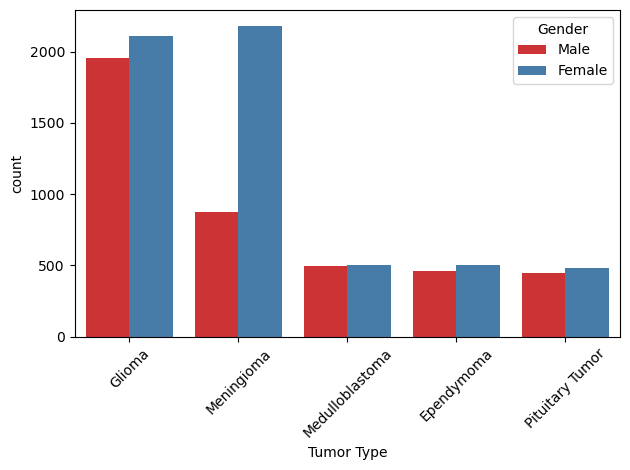

In [37]:
# To visualize the distribution of the 'Tumor Type' column
sns.countplot(data=df, x='Tumor Type', order=df['Tumor Type'].value_counts().index, hue='Gender', palette='Set1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
df.to_csv('Brain Tumor Data.csv', index=False)
print("Saved cleaned file.")

Saved cleaned file.
